### Dəstək Vektorları Metoduna Giriş - Support Vector Machine (SVM)

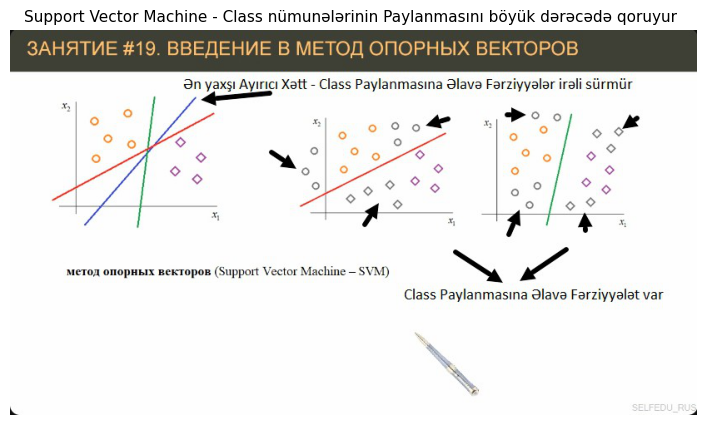

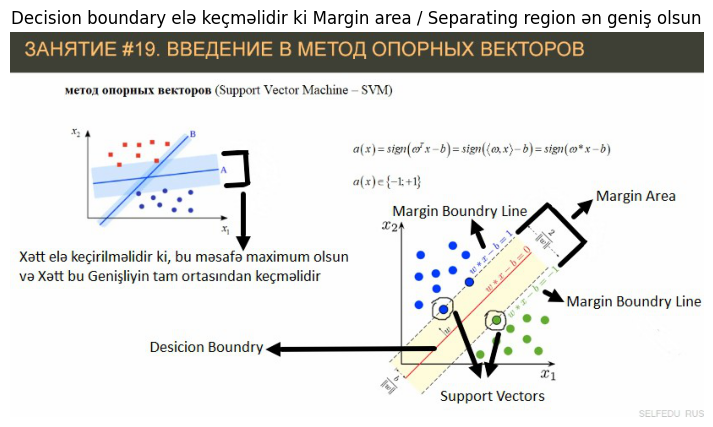

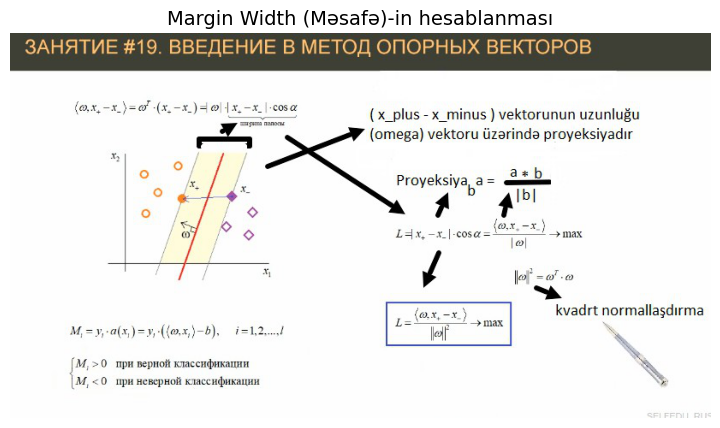

In [15]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_19_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 4):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))      
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Support Vector Machine - Class nümunələrinin Paylanmasını böyük dərəcədə qoruyur """, size='11')
    elif i < 2:
        plt.title("""Decision boundary elə keçməlidir ki Margin area / Separating region ən geniş olsun""", size='12')
    elif i < 3:
        plt.title("""Margin Width (Məsafə)-in hesablanması""", size='14')         
        
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()


$$\langle \omega, x_+ - x_- \rangle = \omega^T (x_+ - x_-) = |\omega| \cdot |x_+ - x_-| \cdot \cos \alpha$$



$$L = |x_+ - x_-| \cdot \cos \alpha = \frac{\langle \omega, x_+ - x_- \rangle}{|\omega|} \to \max$$

$$\|\omega\|^2 = \omega^T \cdot \omega$$

$$L = \frac{\langle \omega, x_+ - x_- \rangle}{\|\omega\|^2} \to \max$$

$$M_i = y_i \cdot a(x_i) = y_i \cdot (\langle \omega, x_i \rangle - b), \quad i = 1, 2, ..., l$$

$$M_i > 0 \quad \text{при верной классификации}$$

$$M_i < 0 \quad \text{при неверной классификации}$$




### Margin width (geometrik məsafə) hesablanması

- **SVM-in riyazi hissəsini başa düşmək istəyirsənsə, bunu sətir-sətir açmaq vacibdir.**

#### 1️⃣

$$
\langle \omega, x_+ - x_- \rangle = \omega^T (x_+ - x_-) = |\omega| \cdot |x_+ - x_-| \cdot \cos \alpha
$$

**İzah:**

* **⟨ω , x₊ − x₋⟩ → bu skalyar hasil (dot product)-dır.**
* **ωᵀ(x₊ − x₋) → matris yazılışıdır.**
* **Sağ tərəf isə dot product-un həndəsi formasıdır:**

$$
|\omega| \cdot |x_+ - x_-| \cdot \cos\alpha
$$

Burada:

* **|ω| → ω vektorunun uzunluğu**
* **|x₊ − x₋| → iki nöqtə arasındakı məsafə**
* **α → ω ilə (x₊ − x₋) arasındakı bucaq**

> **Bu formul göstərir ki, dot product = bir vektorun o birinin bu istiqamətində proyeksiyasıdır.**

$$
$$

#### 🔎 Niyə ( x_+ - x_- ) məsafədir?

x₊ və x₋ iki fərqli sinifdən olan nöqtələrdir.

x₊ − x₋ = bir nöqtədən o birinə gedən vektordur.

Bu vektorun uzunluğu:

$$
|x_+ - x_-|
$$

iki nöqtə arasındakı məsafədir.

Amma SVM-də biz tam məsafəni yox, onun **ω istiqamətində olan hissəsini** istəyirik.


---

#### 2️⃣


**İzah:**

Bu ifadə:

$$
L = |x_+ - x_-| \cdot \cos \alpha = \frac{\langle \omega, x_+ - x_- \rangle}{|\omega|}
$$

olaraq yazılır.

Bu nədir?

> Bu, **(x₊ − x₋) vektorunun ω istiqamətində proyeksiyasıdır.**

Yəni:

> **👉 L = iki Support Vector arasındakı məsafənin ayırıcı xəttə perpendikulyar istiqamətdə olan hissəsi**

> Bu da əslində **margin enidir**.

$$
$$

#### 📌 Proyeksiya hansıdır?

Bu hissə:

$$
|x_+ - x_-| \cos\alpha
$$

Proyeksiya budur.

Bu nəyin proyeksiyasıdır?

- 👉 (x₊ − x₋) vektorunun ω istiqamətinə proyeksiyasıdır.

ω nədir?

ω ayırıcı xəttə (decision boundary) **perpendikulyardır.**

Yəni proyeksiya əslində:

- 👉 iki support vector arasındakı məsafənin ayırıcı xəttə perpendikulyar hissəsidir

Bu da **margin enidir.**


---

#### 3️⃣

$$
|\omega|^2 = \omega^T \omega
$$

**İzah:**

Bu, normanın kvadratıdır.

$$
|\omega| = \sqrt{\omega^T \omega}
$$

Kvadratını götürəndə kök itir.

SVM-də kvadrat istifadə edilir çünki:

* **Kvadrat kök diferensial baxımdan çətindir**
* **Kvadrat funksiyalar optimizasiyada daha rahatdır**
* **Minimum tapmaq asan olur**

---

#### 4️⃣

$$
L = \frac{\langle \omega, x_+ - x_- \rangle}{|\omega|^2} \to \max
$$

Burada artıq normallaşdırma edilib.

Bu o deməkdir ki:

> **ω-nun uzunluğu süni şəkildə böyüdülərək L-ni artırmaq mümkün olmasın deyə, məsələ normaya bölünür.**

Yəni:

👉 Biz istiqaməti optimallaşdırmaq istəyirik Ölçünü yox

Bu səbəbdən normallaşdırma edilir.

$$
$$

#### 📌 Niyə normallaşdırıldı?

Əgər normallaşdırmasaq:

ω-nu 100 dəfə böyütsək, dot product da 100 dəfə böyüyəcək.

Bu süni artım olar.

Biz məsafəni real ölçmək istəyirik.

Ona görə:

$$
\frac{\langle \omega, x \rangle}{|\omega|}
$$

edərək ölçü effektini silirik.

Bu artıq **həqiqi geometrik məsafədir.**

---

#### 5️⃣

$$
M_i = y_i \cdot a(x_i) = y_i \cdot (\langle \omega, x_i \rangle - b)
$$

Bu çox vacibdir.

Burada:

* **yᵢ ∈ {+1, -1}**
* **a(xᵢ) = ω·xᵢ − b → modelin çıxışı**
* **Mᵢ → margin (functional margin)**

Bu nədir?

> **Bu, nöqtənin ayırıcı xəttdən hansı tərəfdə və nə qədər uzaqda olduğunu göstərir.**

---

#### 6️⃣

$$
M_i > 0 \quad \text{doğru klassifikasiya}
$$

Əgər:

* **yᵢ = +1 və model müsbət verirsə → doğru**
* **yᵢ = −1 və model mənfi verirsə → doğru**

Çünki işarələr uyğun gəlir.

---

#### 7️⃣

$$
M_i < 0 \quad \text{səhv klassifikasiya}
$$

**Əgər işarələr ziddirsə → səhv klassifikasiya.**

$$
$$

#### 🎯 Margin nədir?

> Margin — iki sinfi ayıran xətt ilə ən yaxın nöqtələr arasındakı məsafədir.

SVM-in məqsədi:

- 👉 Margin-i maksimum etmək
- 👉 Çünki böyük margin = daha stabil model

$$
$$

#### 🎯 Margin nə üçündür?

- 1️⃣ Model daha robust olur
- 2️⃣ Overfitting azalır
- 3️⃣ Generalization yaxşılaşır
- 4️⃣ Noise-ə qarşı davamlılıq artır

Riyazi olaraq:

$$
\text{Margin} = \frac{2}{|\omega|}
$$

Ona görə də SVM problemi belə yazılır:

$$
\min \frac{1}{2} |\omega|^2
$$

Çünki:

ω kiçik olduqca → margin böyüyür.


### Vidoe Mətn Rus dilində orijinal

<p style="color:#9EC1FF; line-height:1.6;">
**здрасти дорогие друзья я сергей балакирев и мы продолжаем курс по машинному обучению на этом занятии мы рассмотрим довольно известный метод классификации так называемый метод опорных векторов что это такое давайте для простоты положим что у нас двумерное призрака и пространство тогда каждая образ класса может представить точкой на плоскости и пусть образы обучающей выборке распределяется вот эти вот образом весь кружочки изображена это образа этого класса и ромбики образы другого класса и как видите для нашего примера можно построить множество различных разделяющих линий в общем случае гипер плоскостей так что каждый из них будет корректно отделять 1 класс от другого и есть возникает вопрос какое разделение лучше в машинном обучении мы исходим из того что модель обученные по некоторые выборки должна хорошо работать с другими произвольными наборами данных того же распределение то есть модель должна иметь хороший обобщающий способности не быть слишком перри обученной и если с этих позиций посмотреть на проведенные разделяющей линия то чисто интуитивная я бы выбрал вот эту вот синюю почему именно ее смотрите красная и зеленая линия в действительности как бы делает дополнительное предположение о распределении образов красное проходите несколько более горизонтально следовательно она как бы предполагает что образы другие образы которые не включается в обучающую выборку будет распределяться вот так вот вдоль этой самой разделяющей линии а и зеленое проходит более вертикально значит она предполагает что образы не входящего обучающий выборка располагается как то вот так вот конечно самом деле вот эта вот синяя линия делает свои предположения но она чисто визуально в большей степени сохраняет исходное распределение вот это вот идея разделяющей гипер плоскости который бы ориентировалась только на распределение обучающей выборке и по возможности не делала бы дополнительных предположениях о распределении образов в классах положена в основу метода опорных викт ров давайте теперь вот это вот чисто интуитивно и соображения формализуем на уровне математики и ответил на первый вопрос что же это за разделяющей диппер плоскость которая делает минимальное предположения о распределении классов и тем самым приводит к лучшей обобщающий способности алгоритмом классификации с точки зрения svm оптимальный разделяющей диппер плоскость это та которая образует наиболее широкую полосу то есть вот здесь вот есть граничные образы 1 и 2 класса и полоса между этими двумя образами должно быть наибольшей а разделяющей линия или в общем случае гипер плоскость должно проходить по центру этой полосы и почему это так в принципе понятно потому что чем шире полоса тем надежнее классе катар будет отделять образы 1 класс от другого чтобы описать вот это вот идея на уровне математике мы вначале должны задать модель классе катара который фактически определяет уравнение гипер плоскость в признаком пространстве мы выберем самую простую линейную модель вот такого вот вида то есть у нас есть некий вектор параметров омега которая определяет ориентацию вот это вот разделяющая линия или гипер плоскости но и затем мы делаем линейную комбинацию вектор параметров с образом x затем здесь некоторые смещения и у нас получается класть катар линейный классе которого такого твида здесь все вот эти вот три выражения это одно и то же то есть скалярное произведение образа x на вектор омега и минус некоторое смещение б то есть b это число на выходе моделью должна выдавать метки класса данном случае будем полагать что метки это минус 1 и плюс 1 бинарной классификация отличная модель на задано давайте теперь посмотрим как можно определить этот вектор омега чтобы вот этот полоса была как можно более широкая вначале мы будем исходить из того что образы наших классов линейно разделимы то есть мы можем провести линию или гипер плоскость которая полностью точно отделяет образа 1 класса от друг у класса а затем мы обобщим этот случай на линейной неразделимые образы и так если мы имеем дело со линейной раздели маме образами то ширина вот этой вот границы будет определяться граничными образами 1 и 2 классов ну очевидно что максимальная ширина будет как раз упираться вот в эти граничные образы и шире просто быть не может как мы можем рассчитать эту ширину давайте возьмем два каких-нибудь образа стоящих на границе и для класса -1 граничный образ обозначим как x минус а для класса + 1 граничного образ будет x плюс тогда вот такая вот разность икс плюс минус x минус то есть мы получим вот такой вот вектор вот он синеньким и здесь показан при чем направление этого вектора будет совпадать с направлением вектора omega a vector омега определяет как раз ориентацию от этого диппер плоскости то есть вот здесь вот мы вычислим скалярное произведение вот этот вектор a на вектор омега а что такое скалярное произведение двух векторов и школе математики мы знаем это длина вектора омега умноженное на длину вот это вот вектор то есть на разность вот этих вот двух векторов и на косинус угла между ними то есть фактически выделить вот мы делаем проекцию вот это вот вектор a на вектор omega a vector омега всегда перпендикулярен разделяющей диппер плоскости мы с вами это уже знаем и в итоге получаем ширину вот это вот полосы вычисленную на основе вот этих вот двух граничных викторов то есть чисто математически мы можем это записать так л это ширина полосы который будет равна скалярному произведению вектора омега на вот этот вектор и деленная на длину вектора омега зачем мы здесь деле муна длиной вектор омега дело в том что вот эта вот ширина полосы будет зависеть от длины вот это вот vectra omega в даже мы делаем скалярное произведение на вектор омега и от того будет она увеличиваться или уменьшаться соответству нас и ширина полосы тоже будет увеличиваться или уменьшаться тошиба как бы измеряем ширину полосы в единицах вот это вот вектор омега то есть вектор а омега здесь выступает как единичный вектор поэтому чтоб ширина полосы было безразмерной то есть не зависело от длины вектора мега мы вот этот скалярное произведение дополнительно делим на длину этого вектора омега иначе при оптимизационной задачи мы можем просто устремить от вектора омега к плюс бесконечности и как бы ширина у нас тоже будет увеличиваться но как вы понимаете от полной безумия поэтому нам нужно перейти вот к этой безразмерной величины но это выражение можно немножко упростить и вот здесь этого знаменателя используется не единичную норму а квадратично чтобы не вычислять квадратной корни и тогда ширина у нас запишется вот в таком вот виде скалярное произведение деленная на квадратичную норму вот этот вектор омега и эту ширину нам нужно максимизировать то есть найти такой вектор омега при котором вот эту вот ширина полосы было бы наибольшей как решить эту задачу для этого в методе опорных векторов делает следующим образом но во-первых мы вспомним что вот такое понятие как машин отступ определяет насколько далеко находится объект от разделяющей диппер плоскости но и чисто математически определяется вот эти вот выражением метка класса а метка класса это плюс 1 и минус 1 умноженная на ту метку класс который выдает классификатор если метки совпадает то отступ положителен а значит верная классификация а если метки не совпадает то отступ отрицательным то есть неверная классификация так вот величину этого отступ а мы всегда можем нормировать смотрите если ввести некий коэффициент больше нуля то в этот тот отступ мы можем записать и так то есть мы можем просто умножить этот сад на альфа и это эквивалентно тому что мы на альфа изменим вот этот вектор омега и соответственно еще не я б и сути оптимизационной задачи это никак не изменит но зато мы теперь можем подобрать такое значение альфа при котором вот это вот отступ для граничных элементов будет ровно единица и я это запишу математически вот так вот отступ для образа x плюс это будет единица и отступа для образа x midas тоже единица то что эти образы как раз лежат на границе вот этой вот полосы а разделяющие гипер плоскость проходит по центру этой полосы поэтому это всегда можно сделать ну или строго математически мы можем это записать и вот в таком вот виде минимум для отступа оральной единица причем вот это вот омега это по сути дела альфа умноженное omega a b здесь это альфа умноженное на b зачем мы все это делаем смотрите теперь вот эту вот разность вот это скалярное произведение вектора омега на разность вот этих двух векторов по сути дела есть не что иное как скалярное произведение одного вектора на второй вектор и раз они равной единице да вот эти вот опыт по для граничных элементов то мы можем записать что это единица минус -1 и ширина вот это вот полосы будет определяться фактически вот эти вот выражением 2 деленная на квадратичную норму вектора омега потому что вот здесь вот а мы вместо этого выражение можем просто записать двоечку в результате для линейно разделим их образов мы получаем следующий оптимизационной задачи нам нужно максимизировать вот этот выражение по омега и b при условии чтобы отступ и были больше либо равны единице но эту задачу привычно свой как задача минимизации то есть вот здесь вот вместо максимум мы будем искать минимум то есть мы числитель меняю со знаменателем и получается 1 2 на квадратичную норму вот это вот вектор омега то есть получается нам нужно найти такой вектор омега и такое смещение б чтобы минимизировать атакуют квадратичную норму весов и обеспечить чтобы все отступа были строго больше единицы кроме образов которые находятся на границе вот это вот полосы решение вот такой задач по сути дела я это задач квадратического программирования когда мы минимизируем квадраты весовых их центов при линейных ограничениях я понимаю что ты тот материал который излагая он чисто математически но по-другому здесь и не получится наш вот этот метод опорах викторов он имеет вот такое базу и математическое обоснование и кстати это не самое сложное если открыть в литературу и почитайте от по методу опорных векторов то там еще и более зубодробительные есть вывода я сейчас стараюсь представить все максимально просто и так если вы вот этот поняли то вы считаете вы поняли весь мид в то порах викторов потому что следующая вообще не который мы это сделаем это обобщение для линейной неразделимо вы случая то есть когда наши образы линейной неразделимы и это часто и задачи потому что в общем случае когда решается задач классификации я-то всегда возможны ошибки то есть образы они на самом деле линейное неразделимо и как работать вот в такой ситуации как построить метод опорных векторов для реальных условий для этого придумали следующее эвристику давайте разрешим нашему классика тару ошибаться на некоторую величину xie xie вот эти вот переменные косе называется слой ковыряй был сп английски то есть мы для каждого этого образа разрешим некоторое отступление вот от этого строго управила чтобы отступ был не строго больше либо равен единице а мог принимать и меньшие значения понятно что если могут эти вот величина xi устремим к плюс бесконечности то задачек об оптимизации здесь уже не стоит мы можем взять любой вектор омега например 0 и как бы задачи вот это вот оптимизационного нас будет решена но как вы понимаете это не то что нам нужно поэтому здесь мы конечно же можем ошибаться но эта ошибка должна быть как можно меньше то есть вот эти вот переменные xi и должны стремиться к нулю это условию алгоритма минимизация мы можем учесть следующим образом вот здесь вот к квадрату нормы мы добавляем еще такой слагаемое то есть вот это вот сумма xiii тах умноженное на некий гипер параметр c который мы сами задаем и вот такая сумма должна быть минимальна при этом отступы у нас уже записывается вот по такому правилу и дополнительные условия что все вот эти вот переменные xiii должны быть больше либо равна нулю в принципе вот так вот мы с вами переписали метод опорных векторов и за линейно разделим оба случая к линейно неразделимо му и остается последний вопрос как решить вот эту вот систему смотрите что мы можем здесь сделать вот эти вот два последних неравенства можно переписать и вот в таком вот виде а я просто такси и перенес сюда в левой части и у нас получилось вот такой вот неравенства и так как мы решаем задачу поиска минимума вот этих вот коэффициентов кассе и то вот эту же систему можно переписать используя равенство то есть вот когда я здесь используется равенство да то как раз та тетка сие будут минимальное в итоге мы получаем сначала вот такую систему и эту же самую систему можно записать вот по такому правилу то есть мы просто берем максимум из этих двух величин либо ноль либо вот такой вот отступ единице минус отступ вот этот выражение еще записывает вот в таком вот виде а как положительные срезка то есть вот это и это одно и то же положительность резко зачать что все что меньше нуля приравнивается нулю в результате исходной система становится и ковалентно вот такую безусловной минимизация то есть смотрите мы вот это вот выражение вот этот положительный срезку подставили вот сюда вот и у нас получилось вот такая вот задача минимизация или чаще всего это выражение переписывать так вот видео 19 получается обычный сумма а здесь единица на 2 отце и квадрат нормы вектор омега причем минимизация можно делаем только по вектору омега и по параметру b и смотрите что у нас здесь в итоге получилось первое слагаемое это по сути дела функционал качество эмпирический риск а второе слагаемое это l2 фигуре затар для коэффициентов омега причем функции потерь и здесь имеет вот такой вид она изображена зеленой линией и называется хиншоу ос для сравнения здесь также приведена логарифмической функции потерь который мы с вами ранее уже рассматривали то есть фактически метод опорных векторов это решение оптимизационных задачи при функции потерь хедж и эта функция потерь начинает штрафовать если минимальный отступ для объекта становится меньше единицы и никак не штрафует если отступ больше единицы то есть вот до этого хен schloss важно именно ширина полосы между образами двух классов в отличный пример от логистическая функция вот это вот оранжевый график который стремится максимально развести образы классов относительно разделяющей диппер плоскости потому что здесь штраф постепенно уменьшается при увеличении м и никогда не достигает 0 вот округляется на графики функций потерь можно понять как будет строиться алгоритм классификация также вот из метода пор их викторов очень хорошо виден геометрический смысл вот это вот l2 регуляризация фактически он здесь отвечает за максимизацию ширины вот это вот разделяющей полосы и в результате приводит к лучшим обобщающим способностям полученного классификатора на этом мы с вами совершим первые занятия по о своем здесь мы получили общее алгоритм для нахождения параметров линейной модели омегой б а на следующем занятии я отмечу подход с помощью которого можно эффективно решить данную задачу и приведу пример простой реализации метода опорных векторов на python [музыка]**
</p>

### Vidoe Mətn Azərbaycan dilində tərcüməsi

**Salam, əziz dostlar! Mən Sergey Balakirev və biz maşın öyrənmə kursunu davam etdiririk. Bu dərsdə biz kifayət qədər tanınmış klassifikasiya metodunu, sözdə "dayaq vektorları metodu"nu nəzərdən keçirəcəyik.**

**Bu nədir?** Sadəlik üçün fərz edək ki, bizim iki ölçülü əlamətlər fəzamız var. O zaman hər bir sinfin nümunəsini müstəvidə nöqtə kimi təqdim edə bilərik. Tutaq ki, təlim seçimindəki nümunələr bu şəkildə paylanıb: dairələr bir sinfin nümunələri, romblar isə digər sinfin nümunələridir. Gördüyünüz kimi, nümunəmiz üçün müxtəlif ayırıcı xətlər (ümumi halda hiper müstəvilər) qurmaq olar, belə ki, onların hər biri bir sinfi digərindən düzgün ayıracaq.

**Və belə bir sual yaranır: hansı ayırma daha yaxşıdır?** Maşın öyrənməsində biz fərz edirik ki, müəyyən seçim üzərində öyrədilmiş model eyni paylanmaya malik digər təsadüfi verilənlər dəstlərində də yaxşı işləməlidir. Yəni model ümumiləşdirmə qabiliyyətinə malik olmalı, çox öyrənilməmiş (həddən artıq öyrənmə - overfitting) olmamalıdır. Və əgər çəkilmiş ayırıcı xətlərə bu baxımdan yanaşsaq, sırf intuitiv olaraq mən bu mavi xətti seçərdim.

**Niyə məhz onu?** Baxın, qırmızı və yaşıl xətlər əslində nümunələrin paylanması haqqında əlavə fərziyyələr irəli sürür. Qırmızı xətt bir qədər daha üfüqi keçir, ona görə də təlim seçiminə daxil olmayan digər nümunələrin bu ayırıcı xətt boyunca, təxminən belə paylanacağını fərz edir. Yaşıl xətt isə daha şaquli keçir, yəni təlim seçiminə daxil olmayan nümunələrin təxminən bu şəkildə yerləşəcəyini fərz edir. Əlbəttə ki, bu mavi xətt də öz fərziyyələrini irəli sürür, lakin vizual olaraq, o, orijinal paylanmanı daha çox qoruyur. Yalnız təlim seçiminin paylanmasına əsaslanan və siniflərdəki nümunələrin paylanması haqqında əlavə fərziyyələr irəli sürməyən ayırıcı hiper müstəvi ideyası **dayaq vektorları metodunun (SVM) əsasını təşkil edir.**

**Gəlin indi bu sırf intuitiv mülahizələri riyaziyyat dilində rəsmiləşdirək və ilk suala cavab verək:** siniflərin paylanması haqqında minimum fərziyyə edən və bununla da klassifikasiya alqoritmlərinin daha yaxşı ümumiləşdirmə qabiliyyətinə gətirib çıxaran həmin ayırıcı hiper müstəvi nədir?

**SVM nöqteyi-nəzərindən optimal ayırıcı hiper müstəvi, ən geniş zolağı əmələ gətirən hiper müstəvidir.** Yəni burada birinci və ikinci sinfin sərhəd nümunələri var və bu iki nümunə arasındakı zolaq ən böyük olmalıdır. Ayırıcı xətt və ya ümumi halda hiper müstəvi isə bu zolağın mərkəzindən keçməlidir. Bunun niyə belə olduğu prinsipcə aydındır: zolaq nə qədər geniş olsə, klassifikator bir sinfin nümunələrini digər sinifdən bir o qədər etibarlı şəkildə ayıracaq.

**Bu ideyanı riyazi dildə ifadə etmək üçün** əvvəlcə klassifikator modelini təyin etməliyik. Klassifikator əlamətlər fəzasında hiper müstəvi tənliyini müəyyən edir. Biz ən sadə xətti modeli seçirik, təxminən belə bir şey:
y = işarə(〈ω, x〉 - b)
Yəni bizim ω vektor parametrimiz var, o, ayırıcı xəttin və ya hiper müstəvinin istiqamətini təyin edir. Sonra ω parametr vektoru ilə x nümunəsinin xətti kombinasiyasını edirik, burada b əmsalı (sürüşmə - bias) var və nəticədə xətti klassifikator alırıq. Buradakı hər üç ifadə eyni şeydir: x nümunəsinin ω vektoruna skalyar hasili minus b əmsalı (b ədəddir). Çıxışda model sinif etiketlərini verməlidir. Bu halda fərz edək ki, etiketlər binay klassifikasiya üçün -1 və +1-dir.

**Əla, model verilib. İndi baxaq ω vektorunu necə təyin edə bilərik ki, bu zolaq mümkün qədər geniş olsun.** Əvvəlcə siniflərimizin nümunələrinin xətti ayrıla bilən olduğunu fərz edəcəyik, yəni bir sinfin nümunələrini digər sinfin nümunələrindən tam dəqiq ayıran xətt və ya hiper müstəvi çəkə bilərik. Daha sonra bu halı xətti ayrılmayan nümunələr üçün ümumiləşdirəcəyik.

Əgər xətti ayrıla bilən nümunələrlə iş görürüksə, onda bu sərhədin eni birinci və ikinci siniflərin sərhəd nümunələri ilə təyin olunacaq. Aydındır ki, maksimum en məhz bu sərhəd nümunələrinə qədər olacaq və daha geniş ola bilməz.

**Bu eni necə hesablaya bilərik?** Gəlin sərhəddə duran iki nümunə götürək. -1 sinfi üçün sərhəd nümunəsini x⁻, +1 sinfi üçün sərhəd nümunəsini isə x⁺ ilə işarə edək. Onda x⁺ minus x⁻ fərqi, yəni belə bir vektor alırıq (o, burada mavi rənglə göstərilib). Üstəlik, bu vektorun istiqaməti ω vektorunun istiqaməti ilə üst-üstə düşəcək. ω vektoru isə hiper müstəvinin istiqamətini təyin edir.

İndi biz bu a vektorunun ω vektoruna skalyar hasilini hesablayacağıq. İki vektorun skalyar hasili nədir? Məktəb riyaziyyatından bilirik: bu, ω vektorunun uzunluğu, vurulan bu vektorun (yəni iki vektorun fərqinin) uzunluğu, vurulan aralarındakı bucağın kosinusudur. Yəni əslində biz bu a vektorunun ω vektoruna proyeksiyasını edirik. ω vektoru həmişə ayırıcı hiper müstəviyə perpendikulyardır, bunu artıq bilirik. Və nəticədə bu iki sərhəd vektoru əsasında hesablanmış zolağın enini alırıq.

Sırf riyazi olaraq bunu belə yaza bilərik: L (zolağın eni) bərabərdir ω vektorunun bu vektora skalyar hasilinə, bölünsün ω vektorunun uzunluğuna.

**Niyə burada ω vektorunun uzunluğuna bölürük?** Məsələ burasındadır ki, zolağın bu eni ω vektorunun uzunluğundan asılı olacaq. Biz ω vektoruna skalyar hasil edirik və ondan asılı olaraq zolağın eni də artıb-azalacaq. Yəni biz zolağın enini məhz bu ω vektorunun vahidləri ilə ölçürük. Başqa sözlə, burada ω vektoru vahid vektor kimi çıxış edir. Ona görə də zolağın eninin ölçüsüz olması, yəni ω vektorunun uzunluğundan asılı olmaması üçün biz bu skalyar hasili əlavə olaraq ω vektorunun uzunluğuna bölürük. Əks halda, optimallaşdırma məsələsində biz sadəcə ω vektorunu sonsuzluğa yönəldə bilərik və bu da eni süni şəkildə artırar. Ancaq başa düşdüyünüz kimi, bu düzgün yanaşma deyil. Ona görə də bu ölçüsüz kəmiyyətə keçməliyik.

Bu ifadəni bir qədər sadələşdirmək olar. Kvadrat kökü hesablamamaq üçün bu məxrəcdə vahid normadan deyil, kvadratik normadan istifadə edirik. Onda en bizə belə yazılacaq: skalyar hasil bölünsün ω vektorunun kvadratik normasına. Və bu eni maksimallaşdırmalıyıq, yəni elə ω vektoru tapmalıyıq ki, zolağın bu eni ən böyük olsun.

**Bu məsələni necə həll etmək olar?** Bunun üçün dayaq vektorları metodunda aşağıdakı kimi hərəkət edilir. Birincisi, biz "maşın fərqi" (margin) anlayışını xatırlayırıq. Maşın fərqi obyektin ayırıcı hiper müstəvidən nə qədər uzaq olduğunu müəyyən edir. Riyazi olaraq belə təyin olunur: sinfin etikati (bu +1 və ya -1-dir) vurulur klassifikatorun verdiyi etiketə. Əgər etiketlər üst-üstə düşürsə, fərq müsbətdir, yəni düzgün klassifikasiya; əgər etiketlər üst-üstə düşmürsə, fərq mənfidir, yəni səhv klassifikasiya.

Bu fərqin qiymətini hər zaman normallaşdıra bilərik. Baxın: əgər sıfırdan böyük bir α əmsalı tətbiq etsək, bu fərqi belə də yaza bilərik. Yəni biz sadəcə bu cəmi α-ya vura bilərik və bu, ω vektorunu α qədər dəyişməyə və uyğun olaraq b-ni də dəyişməyə bərabərdir. Lakin optimallaşdırma məsələsinin mahiyyəti bunnan dəyişmir. Amma indi biz elə bir α qiyməti seçə bilərik ki, sərhəd elementləri üçün bu fərq düz 1 olsun. Bunu riyazi olaraq belə yazacam: x⁺ nümunəsi üçün fərq 1-ə bərabərdir, x⁻ nümunəsi üçün də fərq 1-ə bərabərdir. Bu nümunələr məhz bu zolağın sərhəddində yerləşir, ayırıcı hiper müstəvi isə zolağın mərkəzindən keçir. Ona görə də bunu həmişə etmək olar. Və ya riyazi olaraq daha ciddi şəkildə bunu belə də yaza bilərik: bütün fərqlərin minimumu 1-ə bərabərdir. Burada ω' əslində α vurulmuş ω-dır, b' isə α vurulmuş b-dir.

**Bütün bunları niyə edirik?** Baxın: indi bu fərq, yəni ω vektorunun bu iki vektorun fərqinə skalyar hasili, mahiyyətcə bir vektorun digər vektorə skalyar hasilidir. Və onlar sərhəd elementləri üçün 1-ə bərabər olduğundan, biz yaza bilərik ki, bu 1 minus -1-dir. Və zolağın eni, əslində, bu ifadə ilə təyin olunacaq: 2 bölünsün ω vektorunun kvadratik normasına. Çünki burada a ifadəsinin yerinə sadəcə 2 yaza bilərik.

Nəticədə xətti ayrıla bilən nümunələr üçün aşağıdakı optimallaşdırma məsələsini alırıq: bu ifadəni ω və b-ya görə maksimallaşdırmalıyıq, şərtlə ki, bütün fərqlər böyük bərabər olsun 1-ə. Lakin bu məsələni minimallaşdırma məsələsi kimi ifadə etmək daha adətdir. Yəni burada maksimum yerinə minimum axtaracağıq. Bunun üçün payla məxrəci dəyişirik və alırıq: 1/2 ω vektorunun kvadratik norması. Yəni elə ω vektoru və elə b sürüşməsi tapmalıyıq ki, çəkilərin kvadratik normasını minimallaşdırsın və bütün fərqlərin (bu zolağın sərhəddində olan nümunələr istisna olmaqla) ciddi şəkildə 1-dən böyük olmasını təmin etsin.

Bu məsələnin həlli mahiyyətcə kvadratik proqramlaşdırma məsələsidir: biz xətti məhdudiyyətlər altında çəki əmsallarının kvadratlarını minimallaşdırırıq. Başa düşürəm ki, izah etdiyim material sırf riyazidir, amma burada başqa cür alınmır. Bu dayaq vektorları metodunun əsası belə bir riyazi əsaslandırmaya malikdir və yeri gəlmişkən, bu ən çətin hissə deyil. Əgər dayaq vektorları metodu ilə bağlı ədəbiyyat açıb oxusanız, orada daha mürəkkəb çıxarış üsullarına rast gələ bilərsiniz. Mən indi hər şeyi mümkün qədər sadə şəkildə təqdim etməyə çalışıram. Əgər siz bunu başa düşdünüzsə, hesab edin ki, dayaq vektorları metodunun bütün mahiyyətini anladınız.

Çünki növbəti addım, edəcəyimiz ümumiləşdirmə xətti ayrılmayan hallar üçündür. Yəni bizim nümunələrimiz xətti olaraq ayrılmır və bu, çox vaxt məsələnin özündə olur. Ümumi halda klassifikasiya məsələsi həll ediləndə həmişə səhvlər mümkündür. Yəni nümunələr əslində xətti olaraq ayrılmır. Belə bir vəziyyətdə necə işləmək olar? Real şərtlər üçün dayaq vektorları metodunu necə qurmaq olar?

Bunun üçün aşağıdakı evristikanı düşünüb tapdılar. Gəlin klassifikatorumuza müəyyən qədər səhv etməyə icazə verək, bu səhvin qiyməti ξ (ksi) olsun. ξ dəyişənlərinə "slack variables" (boşluq dəyişənləri) deyilir, ingiliscə. Yəni biz hər bir nümunə üçün bu ciddi qaydandan (fərqin ciddi şəkildə 1-dən böyük və ya bərabər olması) müəyyən qədər kənara çıxmağa icazə veririk. Aydındır ki, əgər bu ξ qiymətlərini sonsuzluğa yönəltsək, onda optimallaşdırma məsələsi qalmır. Biz istənilən ω vektorunu götürə bilərik, məsələn 0-ı, və optimallaşdırma məsələmiz həll olunmuş olar. Amma başa düşdüyünüz kimi, bu bizə lazım olan şey deyil. Ona görə də burada əlbəttə ki, səhv edə bilərik, amma bu səhv mümkün qədər kiçik olmalıdır. Yəni bu ξ dəyişənləri sıfıra yaxınlaşmalıdır.

Minimallaşdırma alqoritmində bu şərti aşağıdakı kimi nəzərə ala bilərik. Burada kvadratik normaya daha bir hədd əlavə edirik: ξᵢ-lərin cəmi vurulmuş müəyyən bir hiperparametrə (C). Bu hiperparametri biz özümüz təyin edirik. Və belə bir cəmi minimal olmalıdır. Eyni zamanda fərqlər indi bu qayda ilə yazılır və əlavə şərt odur ki, bütün bu ξᵢ dəyişənləri sıfırdan böyük və ya bərabər olmalıdır. Prinsipcə, biz dayaq vektorları metodunu xətti ayrıla bilən haldan xətti ayrılmayan hala beləcə yenidən yazdıq.

**Və son sual qalır: bu sistemi necə həll etmək olar?** Baxın, burada nə edə bilərik? Bu son iki bərabərsizliyi belə də yazmaq olar: Mən sadəcə ξᵢ-ni bura, sol tərəfə keçirirəm və biz belə bir bərabərsizlik alırıq. Və biz bu ξᵢ əmsallarının minimumunu axtarmaq məsələsini həll etdiyimiz üçün, bu eyni sistemi bərabərlikdən istifadə edərək də yazmaq olar. Burada bərabərlikdən istifadə edəndə, ξᵢ elə minimal olacaq. Nəticədə biz əvvəlcə belə bir sistem alırıq və bu eyni sistemi belə bir qayda ilə də yazmaq olar: yəni biz sadəcə bu iki kəmiyyətdən maksimumu götürürük: ya 0, ya da (1 - fərq) ifadəsi. Bu ifadəni daha belə də yazırlar: "positive part" (müsbət hissə) kimi. Yəni bu və bu eyni şeydir. Müsbət hissə o deməkdir ki, sıfırdan kiçik olan hər şey sıfıra bərabərləşdirilir.

Nəticədə ilkin sistem bu cür şərtsiz minimallaşdırmaya ekvivalent olur. Yəni baxın: biz bu ifadəni, bu müsbət hissəni bura qoyuruq və biz belə bir minimallaşdırma məsələsi alırıq. Və ya çox vaxt bu ifadəni belə yazırlar: bu videodakı kimi (slaydda göstərilir). Adi cəm alınır, burada isə 1/2 ω vektorunun kvadratik norması. Üstəlik, minimallaşdırmanı yalnız ω vektoruna və b parametrinə görə edirik.

**Və baxın, sonda nə aldıq?** Birinci hədd mahiyyətcə empirik risk funksionalıdır (keyfiyyət funksionalı), ikinci hədd isə ω əmsalları üçün L2 requlyarizasiyasıdır. Buradakı itki funksiyası isə bu şəklə malikdir (yaşıl xətt) və "hinge loss" (mentəşə itkisi) adlanır. Müqayisə üçün burada əvvəllər baxdığımız loqarifmik itki funksiyası da göstərilib (narıncı xətt).

Yəni əslində dayaq vektorları metodu, "hinge" itki funksiyası ilə optimallaşdırma məsələsinin həllidir. Bu itki funksiyası o zaman cərimə etməyə başlayır ki, obyekt üçün minimal fərq 1-dən kiçik olsun. Fərq 1-dən böyük olarsa, heç bir cərimə tətbiq etmir. Yəni hinge loss üçün iki sinfin nümunələri arasındakı zolağın eni vacibdir. Bu, loqisttik funksiyadan (narıncı qrafik) fərqli olaraq, siniflərin nümunələrini ayırıcı hiper müstəviyə nisbətən maksimum dərəcədə aralamağa çalışır. Çünki loqisttik funksiyada fərq artdıqca cərimə tədricən azalır və heç vaxt 0-a çatmır.

İtki funksiyalarının qrafiklərinə baxaraq klassifikasiya alqoritminin necə qurulacağını anlamaq olar. Həmçinin dayaq vektorları metodundan bu L2 requlyarizasiyasının həndəsi mənası çox yaxşı görünür. O, əslində bu ayırıcı zolağın eninin maksimallaşdırılmasına cavabdehdir və nəticədə alınan klassifikatorun daha yaxşı ümumiləşdirmə qabiliyyətinə gətirib çıxarır.

Bununla da biz SVM-ə dair ilk dərsimizi yekunlaşdırırıq. Burada xətti modelin (ω və b) parametrlərini tapmaq üçün ümumi alqoritm əldə etdik. Növbəti dərsdə mən bu məsələni effektiv həll etməyə imkan verən yanaşmanı qeyd edəcək və Python-da dayaq vektorları metodunun sadə tətbiqinə dair nümunə göstərəcəyəm.

**[Musiqi]**